# Data Preparation
<hr>
This notebook is used to ingest and prepare data for various modules.
<hr>


## Set Up
Create the arrays based on Qilian mask. Have to run before all data ingestion.

In [5]:
import numpy as np
import pandas as pd

# Get coordinates for data
points_file = "./input/qilian.txt"
pts = pd.read_csv(points_file)

# Get unique lat/lon for row/col mapping
lats = np.sort(pts["Latitude"].unique())[::-1]
lons = np.sort(pts["Longitude"].unique())

# Print minimum and maximum lat/lon to verify
print(lats[0])
print(lats[-1])
print(lons[0])
print(lons[-1])

# Map lat/lon to row/col
lat_to_row = {lat: i for i, lat in enumerate(lats)}
lon_to_col = {lon: j for j, lon in enumerate(lons)}

pts["row"] = pts["Latitude"].map(lat_to_row).astype(int)
pts["col"] = pts["Longitude"].map(lon_to_col).astype(int)

nrow, ncol = len(lats), len(lons)
ntime = 365  # for 1979

print(f"Grid size: {nrow} rows x {ncol} cols")

39.721391739
35.921391739
93.663346096
102.863346096
Grid size: 39 rows x 93 cols


## Climate Data

In [9]:
import os

# Change data root depending on the location of the data
data_root = '/Volumes/thesisDrive/Climate data/Daily'
#data_root = '/Volumes/thesisDrive/Permafrost Data TP/daily/Climate data/daily'

# === Config ===
variables = ["TempMean"]
years = range(1980, 2019)  # 1979-2018

# === Output folder for .npy files ===
output_folder = "../data_input/climate_yearly"
os.makedirs(output_folder, exist_ok=True)

# === Loop through each year ===
for year in years:
    print(f"Processing year {year}...")

    # Create a folder for this year
    year_folder = os.path.join(output_folder, str(year))
    os.makedirs(year_folder, exist_ok=True)
    
    # Initialize arrays for this year
    ntime = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    arrays = {var: np.zeros((nrow, ncol, ntime), dtype=np.float32) for var in variables}
    
    # Loop over each point/folder
    for idx, row in pts.iterrows():
        lat, lon = row["Latitude"], row["Longitude"]
        r, c = row["row"], row["col"]
        folder_name = f"{lon}_{lat}"
        file_path = os.path.join(data_root, folder_name, "Climate_data.txt")
        if not os.path.exists(file_path):
            folder_name = f" {lon}_{lat}"
            file_path = os.path.join(data_root, folder_name, "Climate_data.txt")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, sep="\t", parse_dates=["Date"])
            df_year = df[df["Date"].dt.year == year].reset_index(drop=True)
            
            # Fill arrays
            for var in variables:
                col_name = var
                r = int(r)
                c = int(c)  
                # Only fill up to the available number of days (in case leap year differences)
                arrays[var][r, c, :len(df_year)] = df_year[col_name].values

                values = df_year[col_name].values
            # Print the first 5 values if needed
            # print(
            #     f"{var} @ (r={r}, c={c}), "
            #     f"lat={lat}, lon={lon}, "
            #     f"first 5 days: {values[:5]}"
            # )

        else:
            print(f"Missing file: {file_path}")
    
    # Save arrays for this year in the year's folder
    for var, arr in arrays.items():
        npy_path = os.path.join(year_folder, f"{var}.npy")
        np.save(npy_path, arr)
        print(f"Saved {npy_path}")

print("All years processed!")


Processing year 1980...
Saved ../data_input/climate_yearly/1980/TempMean.npy
Processing year 1981...
Saved ../data_input/climate_yearly/1981/TempMean.npy
Processing year 1982...
Saved ../data_input/climate_yearly/1982/TempMean.npy
Processing year 1983...
Saved ../data_input/climate_yearly/1983/TempMean.npy
Processing year 1984...
Saved ../data_input/climate_yearly/1984/TempMean.npy
Processing year 1985...
Saved ../data_input/climate_yearly/1985/TempMean.npy
Processing year 1986...
Saved ../data_input/climate_yearly/1986/TempMean.npy
Processing year 1987...
Saved ../data_input/climate_yearly/1987/TempMean.npy
Processing year 1988...
Saved ../data_input/climate_yearly/1988/TempMean.npy
Processing year 1989...
Saved ../data_input/climate_yearly/1989/TempMean.npy
Processing year 1990...
Saved ../data_input/climate_yearly/1990/TempMean.npy
Processing year 1991...
Saved ../data_input/climate_yearly/1991/TempMean.npy
Processing year 1992...
Saved ../data_input/climate_yearly/1992/TempMean.npy

(39, 93, 365)


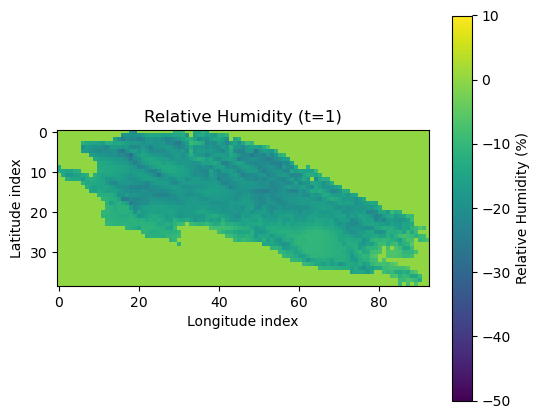

In [10]:
import matplotlib.pyplot as plt

t = 1 # time index

RH = np.load("../data_input/climate_yearly/1979/TempMean.npy")
print(RH.shape)

plt.figure(figsize=(6, 5))
plt.imshow(
    RH[:, :, t],
    cmap="viridis",
    vmin=-50,
    vmax=10,
)
plt.colorbar(label="Relative Humidity (%)")
plt.title(f"Relative Humidity (t={t})")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.show()

### 20-year Averages

In [ ]:
import numpy as np
import os

base_dir = "../data_input/climate_yearly"
variables = ["TempMean"]
periods = {
    "1979-1998": range(1979, 1999),
    "1999-2018": range(1999, 2019),
}

max_days = 365  # Set to 365 because of how the module processes data 

out_dir = "../data_input/climate_20yr_averages"
os.makedirs(out_dir, exist_ok=True)

period_daily_means = {}

for period_name, years in periods.items():
    print(f"Processing {period_name}...")
    period_daily_means[period_name] = {}

    for var in variables:
        daily_stack = []

        for year in years:
            path = os.path.join(base_dir, str(year), f"{var}.npy")
            arr = np.load(path)  # shape (nrow, ncol, ntime)
            nrow, ncol, ntime = arr.shape

            # Remove February 29 if it exists to ensure consistent shape across years
            if ntime > max_days:
                idx_feb29 = 59
                arr = np.delete(arr, idx_feb29, axis=-1)

            daily_stack.append(arr)

        # Stack: (nyears, nrow, ncol, max_days)
        stacked = np.stack(daily_stack, axis=0)
        mean_daily = stacked.mean(axis=0)  # mean over years → (nrow, ncol, max_days)

        period_daily_means[period_name][var] = mean_daily

        # Save each variable
        out_path = os.path.join(out_dir, period_name, f"{var}.npy")
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        np.save(out_path, mean_daily)
        print(f"Saved {out_path} | shape: {mean_daily.shape}")

Processing 1979-1998...
Saved ../data_input/climate_20yr_averages/1979-1998/TempMean.npy | shape: (39, 93, 365)
Processing 1999-2018...
Saved ../data_input/climate_20yr_averages/1999-2018/TempMean.npy | shape: (39, 93, 365)


### Save climate data as .tif for mapping purposes

In [6]:
import numpy as np
import rasterio
from rasterio.transform import from_origin

# Replace with your actual file path
arr = np.load("../data_input/climate_yearly/1979/RH.npy")  # shape: (rows, cols, time)

# --- Select the day you want ---
day_index = 0  # 0 = first day, 1 = second day, etc.
arr_day = arr[:, :, day_index]

# Grid georeferencing (upper-left corner of your grid)
x_min = 93.663346096
y_max = 39.721391739  # adjust to your actual coordinates
pixel_size = 0.1            # 0.1 degree


'''
39.721391739
35.921391739
93.663346096
102.863346096
'''

transform = from_origin(x_min, y_max, pixel_size, pixel_size)

# Output path
out_tif = "climate_day1.tif"

# Save single-band GeoTIFF
with rasterio.open(
    out_tif,
    'w',
    driver='GTiff',
    height=arr_day.shape[0],
    width=arr_day.shape[1],
    count=1,          # single band
    dtype=arr_day.dtype,
    crs="EPSG:4326",
    transform=transform
) as dst:
    dst.write(arr_day, 1)  # write to band 1

print(f"Saved {out_tif}")

Saved climate_day1.tif


## Elevation

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal

## Loading the Raster file and save it as Numpy format
im_width = 93
im_height = 39

## Create numpy array for storing data
elevation = np.zeros((im_height, im_width))

## Writing the loop to read monthly data and store in NumPy array

elevation[:,:] = gdal.Open('/Volumes/thesisDrive/FAO GAEZ/elevation/reprojected elevation.tif').ReadAsArray()

## Save the NumPy array 
np.save('../data_input/terrain/elevation.npy', elevation)

RH = np.load("../data_input/terrain/elevation.npy")
print(RH.shape)

plt.figure(figsize=(6, 5))
plt.imshow(
    RH[:, :],
    cmap="viridis",
    vmin=0,
    vmax=6000,
)
plt.colorbar(label="Relative Humidity (%)")
plt.title(f"Relative Humidity (t={t})")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.show()

/Users/ming-mayhu/miniforge3/envs/pyaez/lib/python3.11/site-packages/osgeo/gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
ERROR 4: /Volumes/thesisDrive/FAO GAEZ/elevation/reprojected elevation.tif: No such file or directory


AttributeError: 'NoneType' object has no attribute 'ReadAsArray'

## SHAW Permafrost Data


### Soil Temperature

In [42]:
import os

data_root = '/Volumes/thesisDrive/Permafrost Data TP/daily/Permafrost data/Daily'
# === Config ===
layers = ["0.00",  "0.02",  "0.07",  "0.13",  "0.23",  "0.39",  "0.66",  "1.11",  "1.84",  "2.75"]
years = range(1980, 2019)  # 1979-2018

# === Output folder for .npy files ===
output_folder = "../data_input/permafrost_yearly"
os.makedirs(output_folder, exist_ok=True)

# === Loop through each year ===
for year in years:
    print(f"Processing year {year}...")

    # Create a folder for this year
    year_folder = os.path.join(output_folder, str(year))
    os.makedirs(year_folder, exist_ok=True)
    
    # Initialize arrays for this year
    ntime = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    arrays = {layer: np.zeros((nrow, ncol, ntime), dtype=np.float32) for layer in layers}
    
    # Loop over each point/folder
    for idx, row in pts.iterrows():
        lat, lon = row["Latitude"], row["Longitude"]
        r, c = row["row"], row["col"]
        folder_name = f"{lon}_{lat}"
        file_path = os.path.join(data_root, folder_name, "temp.txt")
        
        if os.path.exists(file_path):
            # print(file_path)
            try:
                df = pd.read_csv(file_path, sep="\s+", skiprows=1, engine="python", encoding="latin-1")
            except pd.errors.EmptyDataError as e:
                print(f"corrupted file {file_path}: {e}")
                continue
            # print(df.columns)
            df_year = df[df["YR"] == year].reset_index(drop=True)
            # Fill arrays
            for layer in layers:
                col_name = layer
                r = int(r)
                c = int(c)  
                # Only fill up to the available number of days (in case leap year differences)
                arrays[layer][r, c, :len(df_year)] = df_year[col_name].values

        else:
            print(f"Missing file: {file_path}")
    
    # Save arrays for this year in the year's folder
    for layer, arr in arrays.items():
        npy_path = os.path.join(year_folder, "temperature", f"{layer}.npy")
        os.makedirs(os.path.join(year_folder, "temperature"), exist_ok=True)
        np.save(npy_path, arr)
        #print(f"Saved {npy_path}")

print("All years processed!")


Processing year 1980...
Processing year 1981...
Processing year 1982...
Processing year 1983...
Processing year 1984...
Processing year 1985...
Processing year 1986...
Processing year 1987...
Processing year 1988...
Processing year 1989...
Processing year 1990...
Processing year 1991...
Processing year 1992...
Processing year 1993...
Processing year 1994...
Processing year 1995...
Processing year 1996...
Processing year 1997...
Processing year 1998...
Processing year 1999...
Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
All years processed!


### Soil Moisture

In [33]:
import os

data_root = '/Volumes/thesisDrive/Permafrost Data TP/daily/Permafrost data/Daily'
# === Config ===
layers = ["0.00",  "0.02",  "0.07",  "0.13",  "0.23",  "0.39",  "0.66",  "1.11",  "1.84",  "2.75"]
years = range(1988, 2019)  # 1979-2018

# === Output folder for .npy files ===
output_folder = "../data_input/permafrost_yearly"
os.makedirs(output_folder, exist_ok=True)

# === Loop through each year ===
for year in years:
    print(f"Processing year {year}...")

    # Create a folder for this year
    year_folder = os.path.join(output_folder, str(year))
    os.makedirs(year_folder, exist_ok=True)
    
    # Initialize arrays for this year
    ntime = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    arrays = {layer: np.zeros((nrow, ncol, ntime), dtype=np.float32) for layer in layers}
    
    # Loop over each point/folder
    for idx, row in pts.iterrows():
        lat, lon = row["Latitude"], row["Longitude"]
        r, c = row["row"], row["col"]
        folder_name = f"{lon}_{lat}"
        file_path = os.path.join(data_root, folder_name, "liquid.txt")
        
        if os.path.exists(file_path):
            #print(file_path)
            df = pd.read_csv(file_path, sep="\s+", skiprows=1, engine="python", encoding="latin-1")
            #print(df.columns)
            df_year = df[df["YR"] == year].reset_index(drop=True)
            # Fill arrays
            for layer in layers:
                col_name = layer
                r = int(r)
                c = int(c)  
                # Only fill up to the available number of days (in case leap year differences)
                arrays[layer][r, c, :len(df_year)] = df_year[col_name].values

        else:
            print(f"Missing file: {file_path}")
    
    # Save arrays for this year in the year's folder
    for layer, arr in arrays.items():
        npy_path = os.path.join(year_folder, "soil moisture", f"{layer}.npy")
        os.makedirs(os.path.join(year_folder, "soil moisture"), exist_ok=True)
        np.save(npy_path, arr)
        print(f"Saved {npy_path}")

print("All years processed!")


Processing year 1988...
Saved ../data_input/permafrost_yearly/1988/soil moisture/0.00.npy
Saved ../data_input/permafrost_yearly/1988/soil moisture/0.02.npy
Saved ../data_input/permafrost_yearly/1988/soil moisture/0.07.npy
Saved ../data_input/permafrost_yearly/1988/soil moisture/0.13.npy
Saved ../data_input/permafrost_yearly/1988/soil moisture/0.23.npy
Saved ../data_input/permafrost_yearly/1988/soil moisture/0.39.npy
Saved ../data_input/permafrost_yearly/1988/soil moisture/0.66.npy
Saved ../data_input/permafrost_yearly/1988/soil moisture/1.11.npy
Saved ../data_input/permafrost_yearly/1988/soil moisture/1.84.npy
Saved ../data_input/permafrost_yearly/1988/soil moisture/2.75.npy
Processing year 1989...
Saved ../data_input/permafrost_yearly/1989/soil moisture/0.00.npy
Saved ../data_input/permafrost_yearly/1989/soil moisture/0.02.npy
Saved ../data_input/permafrost_yearly/1989/soil moisture/0.07.npy
Saved ../data_input/permafrost_yearly/1989/soil moisture/0.13.npy
Saved ../data_input/permafro

### Find data with issues

In [9]:
import os
import pandas as pd

data_root = '/Volumes/thesisDrive/Permafrost Data TP/daily/Permafrost data/Daily'
years_required = set(range(1979, 2019))  # 1979–2018 inclusive

print("Checking folders...\n")

# Loop through all subfolders in data_root
for folder_name in os.listdir(data_root):
    folder_path = os.path.join(data_root, folder_name)

    # Skip if not a directory
    if not os.path.isdir(folder_path):
        continue

    file_path = os.path.join(folder_path, "liquid.txt")

    # 1️⃣ Check if file exists
    if not os.path.exists(file_path):
        print(f"Missing file: {file_path}")
        continue

    try:
        # 2️⃣ Read file
        df = pd.read_csv(
            file_path,
            sep=r"\s+",
            skiprows=1,
            engine="python",
            encoding="latin-1"
        )

        if "YR" not in df.columns:
            print(f"'YR' column missing in: {file_path}")
            continue

        years_in_file = set(df["YR"].unique())

        # 3️⃣ Check if all required years exist
        if not years_required.issubset(years_in_file):
            missing_years = sorted(years_required - years_in_file)
            print(f"Incomplete years in: {file_path}")
            print(f"Missing years: {missing_years}\n")

    except Exception as e:
        print(f"Error reading file: {file_path}")
        print(f"Error: {e}\n")

print("Check complete!")


Checking folders...

Incomplete years in: /Volumes/thesisDrive/Permafrost Data TP/daily/Permafrost data/Daily/100.263346096_38.321391739/liquid.txt
Missing years: [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]

Missing file: /Volumes/thesisDrive/Permafrost Data TP/daily/Permafrost data/Daily/100.263346096_38.421391739/liquid.txt
Incomplete years in: /Volumes/thesisDrive/Permafrost Data TP/daily/Permafrost data/Daily/100.263346096_38.521391739/liquid.txt
Missing years: [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995]

Incomplete years in: /Volumes/thesisDrive/Permafrost Data TP/daily/Permafrost data/Daily/101.063346096_37.721391739/liquid.txt
Missing years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 20

### Visualization

(39, 93, 365)


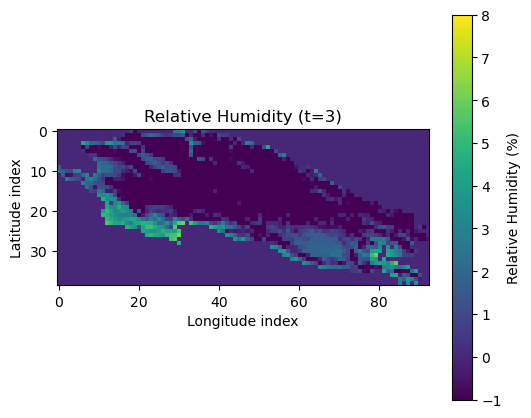

In [48]:

import matplotlib.pyplot as plt

t = 3 # time index

RH = np.load("../data_input/permafrost_yearly/1979/temperature/1.84.npy")
print(RH.shape)

plt.figure(figsize=(6, 5))
plt.imshow(
    RH[:, :, t],
    cmap="viridis",
    vmin=-1,
    vmax=8,
)
plt.colorbar(label="Relative Humidity (%)")
plt.title(f"Relative Humidity (t={t})")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.show()



### Evapotranspiration

In [29]:
import os
import numpy as np
import pandas as pd

data_root = '/Volumes/thesisDrive/Permafrost Data TP/daily/Permafrost data/Daily'

# === Config ===
years = range(1979, 2019)   # change as needed

# === Output folder ===
output_folder = "../data_input/permafrost_yearly"
os.makedirs(output_folder, exist_ok=True)

# === Loop through each year ===
for year in years:
    print(f"\nProcessing year {year}...")

    year_folder = os.path.join(output_folder, str(year))
    os.makedirs(year_folder, exist_ok=True)

    # Determine number of days
    ntime = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365

    # Initialize 3D ET array
    yearly_et = np.zeros((nrow, ncol, ntime), dtype=np.float32)

    # === Loop over grid points ===
    for idx, row in pts.iterrows():

        lat, lon = row["Latitude"], row["Longitude"]
        r, c = int(row["row"]), int(row["col"])

        folder_name = f"{lon}_{lat}"
        file_path = os.path.join(data_root, folder_name, "water.txt")

        if not os.path.exists(file_path):
            print(f"Missing file: {file_path}")
            continue

        # ---------------------------------------------------------
        # AUTO-DETECT HEADER LINE (find line starting with "DAY")
        # ---------------------------------------------------------
        try:
            with open(file_path, "r") as f:
                lines = f.readlines()

            header_line_index = None
            for i, line in enumerate(lines):
                if line.strip().startswith("DAY"):
                    header_line_index = i
                    break

            if header_line_index is None:
                print(f"Header not found in {file_path}")
                continue

            # Read file using detected header row
            df = pd.read_csv(
                file_path,
                sep=r"\s+",
                skiprows=header_line_index,
                engine="python"
            )

        except Exception as e:
            print(f"Error reading {file_path}: {e}")
            continue

        # ---------------------------------------------------------
        # CLEAN COLUMNS
        # ---------------------------------------------------------
        df.columns = df.columns.str.strip()

        if "YR" not in df.columns or "ET" not in df.columns:
            print(f"'YR' or 'ET' column missing in {file_path}")
            print("Detected columns:", df.columns.tolist())
            continue

        # Force numeric types
        df["YR"] = pd.to_numeric(df["YR"], errors="coerce")
        df["ET"] = pd.to_numeric(df["ET"], errors="coerce")

        # ---------------------------------------------------------
        # FILTER YEAR
        # ---------------------------------------------------------
        df_year = df[df["YR"] == year].reset_index(drop=True)

        if df_year.empty:
            continue

        # ---------------------------------------------------------
        # FILL DAILY ARRAY
        # ---------------------------------------------------------
        ndays_available = min(len(df_year), ntime)
        yearly_et[r, c, :ndays_available] = df_year["ET"].values[:ndays_available]


    # -------------------------------------------------------------
    # SAVE OUTPUT
    # -------------------------------------------------------------
    npy_path = os.path.join(year_folder, "ET.npy")
    np.save(npy_path, yearly_et)

    print(f"Saved: {npy_path}")

print("\nAll years processed!")



Processing year 1979...
Saved: ../data_input/permafrost_yearly/1979/ET.npy

Processing year 1980...
Saved: ../data_input/permafrost_yearly/1980/ET.npy

Processing year 1981...
Saved: ../data_input/permafrost_yearly/1981/ET.npy

Processing year 1982...
Saved: ../data_input/permafrost_yearly/1982/ET.npy

Processing year 1983...
Saved: ../data_input/permafrost_yearly/1983/ET.npy

Processing year 1984...
Saved: ../data_input/permafrost_yearly/1984/ET.npy

Processing year 1985...
Saved: ../data_input/permafrost_yearly/1985/ET.npy

Processing year 1986...
Saved: ../data_input/permafrost_yearly/1986/ET.npy

Processing year 1987...
Saved: ../data_input/permafrost_yearly/1987/ET.npy

Processing year 1988...
Saved: ../data_input/permafrost_yearly/1988/ET.npy

Processing year 1989...
Saved: ../data_input/permafrost_yearly/1989/ET.npy

Processing year 1990...
Saved: ../data_input/permafrost_yearly/1990/ET.npy

Processing year 1991...
Saved: ../data_input/permafrost_yearly/1991/ET.npy

Processing 

### ALT and ASM

In [34]:
"""
Compute Active Layer Thickness (ALT) and Available Soil Moisture (ASM)
from soil temperature and soil moisture profiles.

For each year (1979-2018):
    1. Loads daily soil temperature arrays for each depth node and computes
       the active layer bottom depth — the deepest CONTIGUOUSLY thawed layer
       from the surface downward.
    2. Loads daily liquid soil moisture arrays for each depth node and
       sums moisture over all layers within the active layer to produce
       total available soil moisture (mm) for each grid cell and day.

Active layer definition:
    Contiguous thawed zone from the surface downward. If a frozen node is
    encountered, the active layer stops at the bottom of the previous thawed
    node — even if deeper nodes are also thawed.

The surface node (centered at 0.00m, zero thickness) is excluded from
both temperature and soil moisture calculations.

Since ALT is always snapped to a layer bottom depth, no layer can be
partially within the active layer — a layer is either fully included or
fully excluded.

Inputs:
    Temperature  : <BASE_DIR>/<year>/temperature/<depth>.npy
    Soil moisture: <SM_DIR>/<year>/soil moisture/<depth>.npy
    Each file shape: (rows, cols, 365)
    Units: temperature in °C, soil moisture in m³/m³ (volumetric liquid)

Outputs:
    active_layer_<year>.npy       : Active layer bottom depth (m), shape (rows, cols, 365)
    avail_soil_moisture_<year>.npy: Total liquid soil moisture in active layer (mm),
                                    shape (rows, cols, 365)
"""

import numpy as np
import os

# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------

# Base directory for temperature data
BASE_DIR = '../data_input/permafrost_yearly'

# Base directory for soil moisture data
SM_DIR = '../data_input/permafrost_yearly'

# Output directory
OUT_DIR = '../data_input/permafrost_yearly'
os.makedirs(OUT_DIR, exist_ok=True)

# Years to process
YEARS = range(1979, 2019)

# Depth nodes — surface node (0.00m) excluded
CENTER_DEPTHS = [0.02, 0.07, 0.13, 0.23, 0.39, 0.66, 1.11, 1.84, 2.75]

# Bottom depth (m) of each layer — ALT is always one of these values
BOTTOM_DEPTHS = [0.04, 0.10, 0.16, 0.30, 0.48, 0.84, 1.36, 2.32, 3.18]

# Thickness (m) of each layer — used to convert m³/m³ to mm
# Top of layer 0 is 0.00m; top of each subsequent layer = bottom of previous
THICKNESSES = [0.04, 0.06, 0.06, 0.14, 0.18, 0.36, 0.52, 0.96, 0.86]

# Temperature threshold for thaw
THAW_THRESHOLD = 0.0

# -----------------------------------------------------------------------
# Main processing loop
# -----------------------------------------------------------------------

bottom_depths_arr = np.array(BOTTOM_DEPTHS)  # (n_depths,)
thicknesses_arr   = np.array(THICKNESSES)    # (n_depths,)

for year in YEARS:
    print(f'Processing year {year}...')

    # -------------------------------------------------------------------
    # Load temperature and soil moisture stacks
    # Shape: (n_depths, rows, cols, 365)
    # -------------------------------------------------------------------
    temp_stack = []
    sm_stack   = []

    for depth in CENTER_DEPTHS:
        depth_str = f'{depth:.2f}'

        t_path = os.path.join(BASE_DIR, str(year), 'temperature',   f'{depth_str}.npy')
        s_path = os.path.join(SM_DIR,   str(year), 'soil moisture',  f'{depth_str}.npy')

        temp_stack.append(np.load(t_path))
        sm_stack.append(np.load(s_path))

    temp_stack = np.array(temp_stack)  # (n_depths, rows, cols, 365)
    sm_stack   = np.array(sm_stack)    # (n_depths, rows, cols, 365)

    n_depths, rows, cols, days = temp_stack.shape

    # -------------------------------------------------------------------
    # Step 1: Compute active layer bottom depth (ALT)
    # -------------------------------------------------------------------
    thawed       = temp_stack > THAW_THRESHOLD          # (n_depths, rows, cols, 365)
    alt          = np.zeros((rows, cols, days), dtype=np.float32)
    still_thawed = np.ones( (rows, cols, days), dtype=bool)

    for d_idx in range(n_depths):

        contiguous = thawed[d_idx] & still_thawed

        # Assign this layer's bottom depth where contiguously thawed
        alt = np.where(contiguous, bottom_depths_arr[d_idx], alt)

        # Block columns that hit a frozen node
        still_thawed = still_thawed & thawed[d_idx]

        if not still_thawed.any():
            break

    # -------------------------------------------------------------------
    # Step 2: Compute total available soil moisture (ASM) in mm
    # -------------------------------------------------------------------
    # Since ALT is always a layer bottom depth, each layer is either:
    #   - Fully included  : layer bottom depth <= ALT
    #   - Fully excluded  : layer bottom depth >  ALT
    # No partial layers exist.
    #
    # ASM (mm) = sum over included layers of: sm (m³/m³) × thickness (m) × 1000

    asm = np.zeros((rows, cols, days), dtype=np.float32)

    for d_idx in range(n_depths):

        # Layer is included wherever its bottom depth <= ALT
        included = (alt >= bottom_depths_arr[d_idx])  # (rows, cols, 365) boolean

        # Add this layer's contribution: volumetric moisture × thickness × 1000 → mm
        asm += np.where(included, sm_stack[d_idx] * thicknesses_arr[d_idx] * 1000.0, 0.0)

    # -------------------------------------------------------------------
    # Step 3: Save outputs
    # -------------------------------------------------------------------
    alt_path = os.path.join(OUT_DIR, str(year),f'active_layer_depth.npy')
    asm_path = os.path.join(OUT_DIR, str(year), f'avail_soil_moisture.npy')

    np.save(alt_path, alt)
    np.save(asm_path, asm)

    print(f'  ALT saved : {alt_path}  shape={alt.shape}')
    print(f'  ASM saved : {asm_path}  shape={asm.shape}')

print('Done.')

Processing year 1979...
  ALT saved : ../data_input/permafrost_yearly/1979/active_layer_depth.npy  shape=(39, 93, 365)
  ASM saved : ../data_input/permafrost_yearly/1979/avail_soil_moisture.npy  shape=(39, 93, 365)
Processing year 1980...
  ALT saved : ../data_input/permafrost_yearly/1980/active_layer_depth.npy  shape=(39, 93, 366)
  ASM saved : ../data_input/permafrost_yearly/1980/avail_soil_moisture.npy  shape=(39, 93, 366)
Processing year 1981...
  ALT saved : ../data_input/permafrost_yearly/1981/active_layer_depth.npy  shape=(39, 93, 365)
  ASM saved : ../data_input/permafrost_yearly/1981/avail_soil_moisture.npy  shape=(39, 93, 365)
Processing year 1982...
  ALT saved : ../data_input/permafrost_yearly/1982/active_layer_depth.npy  shape=(39, 93, 365)
  ASM saved : ../data_input/permafrost_yearly/1982/avail_soil_moisture.npy  shape=(39, 93, 365)
Processing year 1983...
  ALT saved : ../data_input/permafrost_yearly/1983/active_layer_depth.npy  shape=(39, 93, 365)
  ASM saved : ../data

(39, 93, 365)


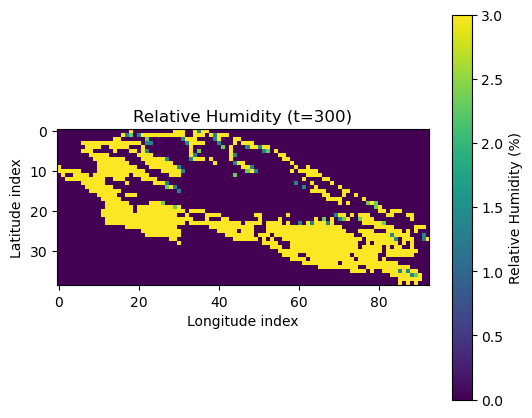

In [39]:

import matplotlib.pyplot as plt

t = 300 # time index

RH = np.load("../data_input/permafrost_yearly/2018/active_layer_depth.npy")
print(RH.shape)

plt.figure(figsize=(6, 5))
plt.imshow(
    RH[:, :, t],
    cmap="viridis",
    vmin=0,
    vmax=3,
)
plt.colorbar(label="Relative Humidity (%)")
plt.title(f"Relative Humidity (t={t})")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.show()



## HWSD

In [44]:
import subprocess
import pandas as pd
import io

mdb_path = "/Users/ming-mayhu/Downloads/HWSD2.mdb"

def read_table(table_name):
    result = subprocess.run(
        ['/opt/homebrew/bin/mdb-export', mdb_path, table_name],
        capture_output=True, text=True
    )
    df = pd.read_csv(io.StringIO(result.stdout))
    print(f"{table_name}: {df.shape[0]} rows, {df.shape[1]} columns")
    return df

tables = ['HWSD2_LAYERS', 'HWSD2_SMU', 'D_TEXTURE', 'D_PHASE', 'D_DRAINAGE', 'D_ROOT_DEPTH']

# Read all tables first
dfs = {}
for table in tables:
    dfs[table] = read_table(table)

# Only write if we have data
output_path = "/Users/ming-mayhu/Downloads/HWSD2_extracted.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for table, df in dfs.items():
        if not df.empty:
            df.to_excel(writer, sheet_name=table, index=False)
            print(f"Written {table}")
        else:
            print(f"SKIPPED {table} — empty!")

print("Done!")

/var/folders/1c/nj742lln0vzcfy2cyjyl1t180000gn/T/ipykernel_47135/3932434819.py:12: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(result.stdout))


HWSD2_LAYERS: 408835 rows, 48 columns
HWSD2_SMU: 29538 rows, 23 columns
D_TEXTURE: 4 rows, 2 columns
D_PHASE: 31 rows, 2 columns
D_DRAINAGE: 7 rows, 3 columns
D_ROOT_DEPTH: 4 rows, 2 columns
Written HWSD2_LAYERS
Written HWSD2_SMU
Written D_TEXTURE
Written D_PHASE
Written D_DRAINAGE
Written D_ROOT_DEPTH
Done!


In [ ]:
import subprocess
import pandas as pd
import io

mdb_path = "/Users/ming-mayhu/Downloads/HWSD2.mdb"

def read_table(table_name):
    result = subprocess.run(
        ['/opt/homebrew/bin/mdb-export', mdb_path, table_name],
        capture_output=True, text=True
    )
    df = pd.read_csv(io.StringIO(result.stdout))
    print(f"{table_name}: {df.shape[0]} rows, {df.shape[1]} columns")
    return df

tables = ['HWSD2_LAYERS', 'HWSD2_SMU', 'D_TEXTURE', 'D_PHASE', 'D_DRAINAGE', 'D_ROOT_DEPTH']

# Read all tables first
dfs = {}
for table in tables:
    dfs[table] = read_table(table)

# Only write if we have data
output_path = "/Users/ming-mayhu/Downloads/HWSD2_extracted.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    for table, df in dfs.items():
        if not df.empty:
            df.to_excel(writer, sheet_name=table, index=False)
            print(f"Written {table}")
        else:
            print(f"SKIPPED {table} — empty!")

print("Done!")

/var/folders/1c/nj742lln0vzcfy2cyjyl1t180000gn/T/ipykernel_47135/3932434819.py:12: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(io.StringIO(result.stdout))


HWSD2_LAYERS: 408835 rows, 48 columns
HWSD2_SMU: 29538 rows, 23 columns
D_TEXTURE: 4 rows, 2 columns
D_PHASE: 31 rows, 2 columns
D_DRAINAGE: 7 rows, 3 columns
D_ROOT_DEPTH: 4 rows, 2 columns
Written HWSD2_LAYERS
Written HWSD2_SMU
Written D_TEXTURE
Written D_PHASE
Written D_DRAINAGE
Written D_ROOT_DEPTH
Done!


In [49]:
layers_smus = set([7001,11103,11108,11110,11111,11120,11122,11124,11128,11129,11130,11131,11132,11134,11136,11145,11148,11149,11151,11158,11161,11164,11166,11167,11170,11171,11172,11173,11174,11175,11179,11180,11181,11182,11230,11232,11233,11235,11236,11238,11249,11255,11256,11257,11260,11262,11265,11268,11270,11271,11273,11279,11285,11287,11289,11290,11291,11294,11295,11296,11301,11302,11314,11328,11331,11335,11341,11349,11351,11352,11353,11355,11356,11357,11385,11387,11400,11404,11413,11425,11454,11460,11518,11535,11538,11539,11540,11543,11551,11553,11555,11561,11568,11573,11581,11686,11687,11697,11698,11700,11701,11705,11711,11719,11721,11724,11725,11727,11728,11730,11736,11741,11748,11752,11755,11765,11926,11927,11930,11933])

map_smus = set([7001,11103,11108,11110,11111,11120,11122,11124,11128,11129,11130,11131,11132,11134,11136,11145,11148,11149,11151,11158,11161,11164,11166,11167,11170,11171,11172,11173,11174,11175,11179,11180,11181,11182,11230,11232,11233,11235,11236,11238,11249,11255,11256,11257,11260,11262,11265,11268,11270,11271,11273,11279,11285,11287,11289,11290,11291,11294,11295,11296,11301,11302,11314,11328,11331,11335,11341,11349,11351,11352,11353,11355,11356,11357,11385,11387,11400,11404,11413,11425,11454,11460,11518,11535,11538,11539,11540,11543,11551,11553,11555,11561,11568,11573,11581,11686,11687,11697,11698,11700,11701,11705,11711,11719,11721,11724,11725,11727,11728,11730,11736,11741,11748,11752,11755,11765,11926,11927,11930,11933])

missing = map_smus - layers_smus
print("In map but NOT in layers:", missing)

In map but NOT in layers: set()


### Soil Organic Carbon

In [52]:
"""
Disaggregate Wang et al. cumulative SOC stock rasters (kg/m2)
into HWSD-compatible depth layers d1-d7.

Wang et al. inputs (cumulative from surface):
    soc-30.tif   -> 0-30 cm
    soc-50.tif   -> 0-50 cm
    soc-100.tif  -> 0-100 cm
    soc-200.tif  -> 0-200 cm

HWSD output layers:
    d1: 0-20 cm
    d2: 20-40 cm
    d3: 40-60 cm
    d4: 60-80 cm
    d5: 80-100 cm
    d6: 100-150 cm
    d7: 150-200 cm
"""

import numpy as np
import rasterio
import os

# ── Configuration ────────────────────────────────────────────────────────────

INPUT_DIR = "/Volumes/thesisDrive/Input Data/soc"   # folder containing the soc-XX.tif files
OUTPUT_DIR = "../data_input/soc"  # folder to write d1-d7 rasters (optional)

INPUT_FILES = {
    30:  os.path.join(INPUT_DIR, "soc-30.tif"),
    50:  os.path.join(INPUT_DIR, "soc-50.tif"),
    100: os.path.join(INPUT_DIR, "soc-100.tif"),
    200: os.path.join(INPUT_DIR, "soc-200.tif"),
}

# ── Read rasters ─────────────────────────────────────────────────────────────

cumulative = {}
profile = None  # rasterio metadata from first file (used for writing)

for depth, path in INPUT_FILES.items():
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        nodata = src.nodata
        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)
        cumulative[depth] = data
        if profile is None:
            profile = src.profile.copy()
            profile.update(dtype="float32", nodata=np.nan)

print("Rasters loaded:")
for d, arr in cumulative.items():
    print(f"  0-{d} cm: shape={arr.shape}, mean={np.nanmean(arr):.3f} kg/m2")

# ── Derive incremental Wang et al. layers ────────────────────────────────────
# These are SOC stocks for each specific interval (not cumulative)

inc_0_30   = cumulative[30]                          # 0-30 cm
inc_30_50  = cumulative[50]  - cumulative[30]        # 30-50 cm
inc_50_100 = cumulative[100] - cumulative[50]        # 50-100 cm
inc_100_200= cumulative[200] - cumulative[100]       # 100-200 cm

# ── Disaggregate to HWSD layers (uniform distribution within each interval) ──
#
# Fractions are: (overlap thickness) / (Wang interval thickness)
#
# d1: 0-20 cm   <- 20/30 of inc_0_30
# d2: 20-40 cm  <- 10/30 of inc_0_30  +  10/20 of inc_30_50
# d3: 40-60 cm  <- 10/20 of inc_30_50 +  10/50 of inc_50_100
# d4: 60-80 cm  <- 20/50 of inc_50_100
# d5: 80-100 cm <- 20/50 of inc_50_100
# d6: 100-150 cm<- 50/100 of inc_100_200
# d7: 150-200 cm<- 50/100 of inc_100_200

d1 = (20/30) * inc_0_30
d2 = (10/30) * inc_0_30  + (10/20) * inc_30_50
d3 = (10/20) * inc_30_50 + (10/50) * inc_50_100
d4 = (20/50) * inc_50_100
d5 = (20/50) * inc_50_100
d6 = (50/100) * inc_100_200
d7 = (50/100) * inc_100_200

layers = {
    "d1": d1,
    "d2": d2,
    "d3": d3,
    "d4": d4,
    "d5": d5,
    "d6": d6,
    "d7": d7,
}

# ── Print summary ─────────────────────────────────────────────────────────────

depth_labels = {
    "d1": "0-20 cm",
    "d2": "20-40 cm",
    "d3": "40-60 cm",
    "d4": "60-80 cm",
    "d5": "80-100 cm",
    "d6": "100-150 cm",
    "d7": "150-200 cm",
}

print("\nDisaggregated HWSD layers (kg/m2):")
for name, arr in layers.items():
    print(f"  {name} ({depth_labels[name]}): mean={np.nanmean(arr):.3f}, "
          f"min={np.nanmin(arr):.3f}, max={np.nanmax(arr):.3f}")

# Sanity check: d1+d2+...+d7 should equal cumulative 0-200
total = sum(layers.values())
diff = np.nanmean(np.abs(total - cumulative[200]))
print(f"\nSanity check — mean absolute difference from 0-200 total: {diff:.6f} kg/m2")

# ── Save each layer as a numpy file ──────────────────────────────────────────

for name, arr in layers.items():
    out_path = os.path.join(OUTPUT_DIR, f"wang_{name}.npy")
    np.save(out_path, arr)
    print(f"  Saved: {out_path}")

print("\nDone. Load with e.g.: d1 = np.load('wang_d1.npy')")

Rasters loaded:
  0-30 cm: shape=(39, 93), mean=4.343 kg/m2
  0-50 cm: shape=(39, 93), mean=5.934 kg/m2
  0-100 cm: shape=(39, 93), mean=7.775 kg/m2
  0-200 cm: shape=(39, 93), mean=10.811 kg/m2

Disaggregated HWSD layers (kg/m2):
  d1 (0-20 cm): mean=2.895, min=0.641, max=8.337
  d2 (20-40 cm): mean=2.243, min=0.625, max=7.069
  d3 (40-60 cm): mean=1.164, min=0.398, max=3.950
  d4 (60-80 cm): mean=0.736, min=0.120, max=3.390
  d5 (80-100 cm): mean=0.736, min=0.120, max=3.390
  d6 (100-150 cm): mean=1.518, min=0.595, max=3.326
  d7 (150-200 cm): mean=1.518, min=0.595, max=3.326

Sanity check — mean absolute difference from 0-200 total: 0.000000 kg/m2
  Saved: ../data_input/soc/wang_d1.npy
  Saved: ../data_input/soc/wang_d2.npy
  Saved: ../data_input/soc/wang_d3.npy
  Saved: ../data_input/soc/wang_d4.npy
  Saved: ../data_input/soc/wang_d5.npy
  Saved: ../data_input/soc/wang_d6.npy
  Saved: ../data_input/soc/wang_d7.npy

Done. Load with e.g.: d1 = np.load('wang_d1.npy')


In [78]:
"""
Convert Wang et al. disaggregated SOC stocks (kg/m2) to SOC%
for layers d1-d7 using HWSD SMU raster and per-layer Excel sheets.

Inputs:
    - wang_d1.npy ... wang_d7.npy  : SOC stocks per HWSD layer
    - hwsd.tif                     : HWSD raster with SMU codes
    - qtp_topsoil.xlsx             : Excel with sheets D1-D7,
                                     each containing: CODE, BULK (g/cm3), COARSE (%)

Outputs:
    - soc_pct_d1.npy ... soc_pct_d7.npy
"""

import numpy as np
import rasterio
import pandas as pd

# ── Configuration ─────────────────────────────────────────────────────────────

WANG_DIR   = "../data_input/soc/"
HWSD_PATH  = "/Volumes/thesisDrive/Input Data/hwsd.tif"
EXCEL_PATH = "../data_input/soil_inputs/qtp_topsoil.xlsx"
OUT_DIR    = "../data_input/soc/"

# Layer name -> depth in metres
LAYERS = {
    "d1": 0.20,   # 0-20 cm
    "d2": 0.20,   # 20-40 cm
    "d3": 0.20,   # 40-60 cm
    "d4": 0.20,   # 60-80 cm
    "d5": 0.20,   # 80-100 cm
    "d6": 0.50,   # 100-150 cm
    "d7": 0.50,   # 150-200 cm
}

# ── Load HWSD SMU raster (once) ───────────────────────────────────────────────

with rasterio.open(HWSD_PATH) as src:
    hwsd_nodata = src.nodata
    smu_raw     = src.read(1)

smu = smu_raw.astype(np.float32)
if hwsd_nodata is not None:
    smu = np.where(smu == hwsd_nodata, np.nan, smu)

unique_smus = np.unique(smu[~np.isnan(smu)])
print(f"Loaded HWSD SMU raster: shape={smu.shape}, unique SMUs={unique_smus.size}")

# ── Process each layer ────────────────────────────────────────────────────────

for layer, depth_m in LAYERS.items():

    print(f"\n── {layer.upper()} (depth={depth_m} m) ──")

    # Load Wang numpy array
    wang_path = f"{WANG_DIR}wang_{layer}.npy"
    soc_stock = np.load(wang_path).astype(np.float32)
    print(f"  Loaded {wang_path}: mean={np.nanmean(soc_stock):.3f} kg/m2")

    # Load corresponding Excel sheet (sheet name matches layer: D1, D2, ...)
    sheet_name = layer.upper()
    df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name, dtype={"CODE": float})
    df = df[["CODE", "BULK", "GRC", "OC"]].dropna(subset=["CODE"])

    bulk_lookup   = dict(zip(df["CODE"], df["BULK"]))
    coarse_lookup = dict(zip(df["CODE"], df["GRC"]))
    print(f"  Loaded sheet '{sheet_name}': {len(df)} SMU records")

    # Map SMU codes to BULK and COARSE arrays
    bulk_arr   = np.full(smu.shape, np.nan, dtype=np.float32)
    coarse_arr = np.full(smu.shape, np.nan, dtype=np.float32)

    missing = []
    for code in unique_smus:
        mask = smu == code
        if code in bulk_lookup:
            bulk_arr[mask]   = bulk_lookup[code]
            coarse_arr[mask] = coarse_lookup.get(code, 0.0)
        else:
            missing.append(code)

    if missing:
        print(f"  Warning: {len(missing)} SMU codes not found in sheet: {missing[:10]}")
    
    bulk_arr   = np.where(bulk_arr < 0,   1.3, bulk_arr)
    coarse_arr = np.where(coarse_arr < 0, 0.0, coarse_arr)
    # Load HWSD OC for this layer as fallback
    oc_hwsd = np.full(smu.shape, np.nan, dtype=np.float32)
    oc_lookup = dict(zip(df["CODE"], df["OC"]))
    for code in unique_smus:
        mask = smu == code
        if code in oc_lookup:
            val = oc_lookup[code]
            oc_hwsd[mask] = val if val >= 0 else np.nan  # mask negative sentinels

    # Fill HWSD OC NaNs with layer mean as last resort
    oc_hwsd = np.where(np.isnan(oc_hwsd), np.nanmean(oc_hwsd), oc_hwsd)

    # Convert BULK g/cm3 -> kg/m3
    bulk_kgm3 = bulk_arr * 1000.0

    # SOC% = SOCS * 100 / (BD * depth * (1 - coarse/100))
    denominator = bulk_kgm3 * depth_m * (1.0 - coarse_arr / 100.0)

    with np.errstate(invalid="ignore", divide="ignore"):
        soc_pct = np.where(denominator > 0, soc_stock * 100.0 / denominator, np.nan)

    soc_pct = np.where(np.isnan(soc_pct), oc_hwsd, soc_pct)
    print(f"  SOC% -> mean={np.nanmean(soc_pct):.3f}, "
          f"min={np.nanmin(soc_pct):.3f}, max={np.nanmax(soc_pct):.3f}, "
          f"NaN={np.isnan(soc_pct).sum()}")

    # Save
    out_path = f"{OUT_DIR}soc_pct_{layer}.npy"
    np.save(out_path, soc_pct)
    print(f"  Saved: {out_path}")

print("\nAll layers complete.")

Loaded HWSD SMU raster: shape=(39, 93), unique SMUs=120

── D1 (depth=0.2 m) ──
  Loaded ../data_input/soc/wang_d1.npy: mean=2.895 kg/m2
  Loaded sheet 'D1': 120 SMU records
  SOC% -> mean=1.244, min=0.226, max=9.453, NaN=0
  Saved: ../data_input/soc/soc_pct_d1.npy

── D2 (depth=0.2 m) ──
  Loaded ../data_input/soc/wang_d2.npy: mean=2.243 kg/m2
  Loaded sheet 'D2': 120 SMU records
  SOC% -> mean=1.016, min=0.143, max=7.383, NaN=0
  Saved: ../data_input/soc/soc_pct_d2.npy

── D3 (depth=0.2 m) ──
  Loaded ../data_input/soc/wang_d3.npy: mean=1.164 kg/m2
  Loaded sheet 'D3': 120 SMU records
  SOC% -> mean=0.454, min=0.123, max=4.450, NaN=0
  Saved: ../data_input/soc/soc_pct_d3.npy

── D4 (depth=0.2 m) ──
  Loaded ../data_input/soc/wang_d4.npy: mean=0.736 kg/m2
  Loaded sheet 'D4': 120 SMU records
  SOC% -> mean=0.295, min=0.050, max=2.779, NaN=0
  Saved: ../data_input/soc/soc_pct_d4.npy

── D5 (depth=0.2 m) ──
  Loaded ../data_input/soc/wang_d5.npy: mean=0.736 kg/m2
  Loaded sheet 'D5': 12

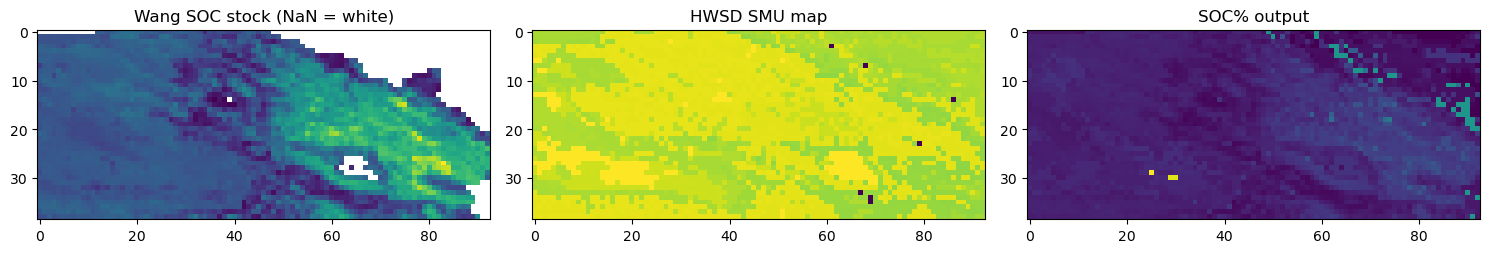

Wang NaNs: 472
SMU NaNs: 0
SOC% NaNs: 0


In [79]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(soc_stock, cmap='viridis')
axes[0].set_title('Wang SOC stock (NaN = white)')

axes[1].imshow(smu, cmap='viridis')
axes[1].set_title('HWSD SMU map')

axes[2].imshow(soc_pct, cmap='viridis')
axes[2].set_title('SOC% output')

plt.tight_layout()
plt.show()

print(f"Wang NaNs: {np.isnan(soc_stock).sum()}")
print(f"SMU NaNs: {np.isnan(smu).sum()}")
print(f"SOC% NaNs: {np.isnan(soc_pct).sum()}")

(39, 93)


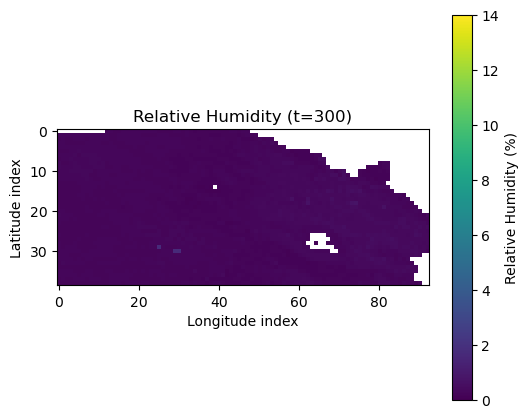

In [76]:

import matplotlib.pyplot as plt

RH = np.load("../data_input/soc/soc_pct_d7.npy")
print(RH.shape)

plt.figure(figsize=(6, 5))
plt.imshow(
    RH[:, :],
    cmap="viridis",
    vmin=0,
    vmax=14,
)
plt.colorbar(label="Relative Humidity (%)")
plt.title(f"Relative Humidity (t={t})")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.show()



In [83]:
from osgeo import gdal
ds = gdal.Open("../data_input/qilian mask.tif")
gt = ds.GetGeoTransform()
xmin = gt[0]
xmax = gt[0] + gt[1] * ds.RasterXSize
ymax = gt[3]
ymin = gt[3] + gt[5] * ds.RasterYSize  # gt[5] is negative
TARGET_EXTENT = [xmin, xmax, ymin, ymax]
print(TARGET_EXTENT)

[93.663346096, 102.963346096, 35.821391739, 39.721391739]


# Soil Ice Content

In [14]:
"""
preprocess_ice_content.py

Loads SHAW ice.txt point data and saves per-layer .npy arrays,
mirroring the structure of the soil moisture preprocessing.

Output: data_input/ice_yearly/{year}/ice/{layer}.npy
        Shape: (rows, cols, days_of_year), float32, units: m³/m³

Run after this to compute depth-weighted annual mean ice (mm):
    aggregate_ice_content.py
"""

import os
import numpy as np
import pandas as pd

# === Config ===
data_root = '/Volumes/thesisDrive/Permafrost Data TP/daily/Permafrost data/Daily'

layers = ["0.00", "0.02", "0.07", "0.13", "0.23", "0.39", "0.66", "1.11", "1.84", "2.75"]

# Layer thicknesses (m) — midpoint-to-midpoint, same as used for soil moisture AWC
layer_thickness = {
    "0.00": 0.02,
    "0.02": 0.05,
    "0.07": 0.06,
    "0.13": 0.10,
    "0.23": 0.16,
    "0.39": 0.27,
    "0.66": 0.45,
    "1.11": 0.73,
    "1.84": 0.91,
    "2.75": 0.50,   # adjust if you have a defined bottom boundary
}

years = range(1979, 2019)

output_folder = "../data_input/ice_yearly"
os.makedirs(output_folder, exist_ok=True)

# === Load grid info (reuse pts, nrow, ncol from your existing setup) ===
# pts must have columns: Latitude, Longitude, row, col
# nrow, ncol must match your permafrost_qilian.tif grid
# Import these from your existing preprocessing environment or define here:
# from your_grid_setup import pts, nrow, ncol

# --- placeholder: replace with your actual pts / nrow / ncol ---
# pts = pd.read_csv("../data_input/grid_points.csv")
# nrow, ncol = 90, 150
# ---------------------------------------------------------------

for year in years:
    print(f"Processing year {year}...")

    year_folder = os.path.join(output_folder, str(year), "ice")
    os.makedirs(year_folder, exist_ok=True)

    ntime = 366 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 365
    arrays = {layer: np.zeros((nrow, ncol, ntime), dtype=np.float32) for layer in layers}

    for idx, row in pts.iterrows():
        lat, lon = row["Latitude"], row["Longitude"]
        r, c = int(row["row"]), int(row["col"])
        folder_name = f"{lon}_{lat}"
        file_path = os.path.join(data_root, folder_name, "ice.txt")

        if not os.path.exists(file_path):
            print(f"Missing: {file_path}")
            continue
        df = pd.read_csv(file_path, sep=r"\s+", engine="python", encoding="latin-1")
        df.columns = df.columns.str.replace('"', '').str.strip()
        # df = pd.read_csv(file_path, sep=r"\s+", skiprows=0, engine="python", encoding="latin-1")
        # print(df.head())    
        # print(df.columns.tolist())
        # print(df.dtypes)
        df_year = df[df["YR"].astype(int) == year].reset_index(drop=True)

        if df_year.empty:
            continue

        for layer in layers:
            col_name = f"X{layer}"          # ice.txt uses X-prefixed columns
            if col_name not in df_year.columns:
                print(f"  Column {col_name} missing in {file_path}, skipping")
                continue
            n = min(len(df_year), ntime)
            arrays[layer][r, c, :n] = df_year[col_name].values[:n]

    for layer, arr in arrays.items():
        npy_path = os.path.join(year_folder, f"{layer}.npy")
        np.save(npy_path, arr)

    print(f"  Saved {len(layers)} layer files for {year}")

print("Done — per-layer ice content arrays saved.")

Processing year 1979...
  Saved 10 layer files for 1979
Processing year 1980...
  Saved 10 layer files for 1980
Processing year 1981...
  Saved 10 layer files for 1981
Processing year 1982...
  Saved 10 layer files for 1982
Processing year 1983...
  Saved 10 layer files for 1983
Processing year 1984...
  Saved 10 layer files for 1984
Processing year 1985...
  Saved 10 layer files for 1985
Processing year 1986...
  Saved 10 layer files for 1986
Processing year 1987...
  Saved 10 layer files for 1987
Processing year 1988...
  Saved 10 layer files for 1988
Processing year 1989...
  Saved 10 layer files for 1989
Processing year 1990...
  Saved 10 layer files for 1990
Processing year 1991...
  Saved 10 layer files for 1991
Processing year 1992...
  Saved 10 layer files for 1992
Processing year 1993...
  Saved 10 layer files for 1993
Processing year 1994...
  Saved 10 layer files for 1994
Processing year 1995...
  Saved 10 layer files for 1995
Processing year 1996...
  Saved 10 layer files f

In [23]:
"""
aggregate_ice_content.py

For each pixel-year, computes the annual maximum of total soil column ice (mm),
summed across all layers regardless of ALT position.

Annual maximum = peak frozen state (winter), when total ice is greatest.
A declining trend over time = net ice loss from the soil column = permafrost degradation.

Ice (mm) = volumetric (m³/m³) × layer thickness (m) × 1000, summed over all layers.

Outputs:
    ice_processed/permafrost_ice_annual.npy     shape (n_years, rows, cols)
    ice_processed/permafrost_ice_{year}.npy     per-year files
    ice_processed/permafrost_ice_period1.npy    mean over 1979-1998
    ice_processed/permafrost_ice_period2.npy    mean over 1999-2018
    ice_processed/permafrost_ice_delta.npy      period2 - period1 (negative = ice loss)
"""

import os
import numpy as np

# === Config ===
LAYERS = ["0.02", "0.07", "0.13", "0.23", "0.39", "0.66", "1.11", "1.84", "2.75"]

THICKNESSES = {
    "0.02": 0.04,
    "0.07": 0.06,
    "0.13": 0.06,
    "0.23": 0.14,
    "0.39": 0.18,
    "0.66": 0.36,
    "1.11": 0.52,
    "1.84": 0.96,
    "2.75": 0.86,
}

years = list(range(1979, 2019))
ice_root = "../data_input/ice_yearly"
output_folder = "../data_input/ice_processed"
os.makedirs(output_folder, exist_ok=True)

# === Infer grid size ===
sample = np.load(os.path.join(ice_root, str(years[0]), "ice", f"{LAYERS[0]}.npy"))
nrow, ncol = sample.shape[0], sample.shape[1]
print(f"Grid: {nrow} x {ncol}")

pf_ice_annual = np.full((len(years), nrow, ncol), np.nan, dtype=np.float32)

for yi, year in enumerate(years):
    print(f"Aggregating {year}...")

    # Accumulate daily total column ice across all layers: (rows, cols, 365)
    ice_daily = np.zeros((nrow, ncol, 365), dtype=np.float32)

    for layer in LAYERS:
        npy_path = os.path.join(ice_root, str(year), "ice", f"{layer}.npy")
        if not os.path.exists(npy_path):
            print(f"  Missing ice layer {layer}, skipping")
            continue

        arr      = np.load(npy_path)          # (rows, cols, days)
        thick_mm = THICKNESSES[layer] * 1000
        ice_mm   = arr * thick_mm             # (rows, cols, days)

        # Handle leap years in ice arrays
        if ice_mm.shape[2] == 366:
            ice_mm = np.delete(ice_mm, 59, axis=2)  # remove Feb 29

        ice_daily += ice_mm

    # Annual maximum = peak frozen state
    pf_ice_annual[yi] = np.max(ice_daily, axis=2)

    # Save individual year file
    year_out = os.path.join(output_folder, f"permafrost_ice_{year}.npy")
    np.save(year_out, pf_ice_annual[yi])

    print(f"  mean: {np.nanmean(pf_ice_annual[yi]):.2f} mm  "
          f"max: {np.nanmax(pf_ice_annual[yi]):.2f} mm")

# === Save full timeseries ===
np.save(os.path.join(output_folder, "permafrost_ice_annual.npy"), pf_ice_annual)
print("Saved permafrost_ice_annual.npy — shape:", pf_ice_annual.shape)

# === Period means and delta ===
idx1 = [i for i, y in enumerate(years) if 1979 <= y <= 1998]
idx2 = [i for i, y in enumerate(years) if 1999 <= y <= 2018]

p1    = np.nanmean(pf_ice_annual[idx1], axis=0)
p2    = np.nanmean(pf_ice_annual[idx2], axis=0)
delta = p2 - p1   # negative = ice loss

np.save(os.path.join(output_folder, "permafrost_ice_period1.npy"), p1)
np.save(os.path.join(output_folder, "permafrost_ice_period2.npy"), p2)
np.save(os.path.join(output_folder, "permafrost_ice_delta.npy"),   delta)

print(f"Period means saved. Mean delta: {np.nanmean(delta):.2f} mm  (negative = ice loss)")
print("Done.")

Grid: 39 x 93
Aggregating 1979...
  mean: 153.07 mm  max: 1228.75 mm
Aggregating 1980...
  mean: 154.06 mm  max: 1225.56 mm
Aggregating 1981...
  mean: 148.69 mm  max: 1226.62 mm
Aggregating 1982...
  mean: 153.58 mm  max: 1224.64 mm
Aggregating 1983...
  mean: 157.86 mm  max: 1229.54 mm
Aggregating 1984...
  mean: 157.98 mm  max: 1230.45 mm
Aggregating 1985...
  mean: 151.34 mm  max: 1227.38 mm
Aggregating 1986...
  mean: 153.61 mm  max: 1227.14 mm
Aggregating 1987...
  mean: 147.77 mm  max: 1225.98 mm
Aggregating 1988...
  mean: 145.09 mm  max: 1224.15 mm
Aggregating 1989...
  mean: 153.96 mm  max: 1229.31 mm
Aggregating 1990...
  mean: 152.95 mm  max: 1229.96 mm
Aggregating 1991...
  mean: 145.13 mm  max: 1224.84 mm
Aggregating 1992...
  mean: 145.26 mm  max: 1214.32 mm
Aggregating 1993...
  mean: 149.52 mm  max: 1224.50 mm
Aggregating 1994...
  mean: 146.31 mm  max: 1226.24 mm
Aggregating 1995...
  mean: 146.82 mm  max: 1229.35 mm
Aggregating 1996...
  mean: 147.01 mm  max: 1229.59

In [20]:
import numpy as np

# Load one year's ALT and ice for a single pixel you know has permafrost
alt = np.load("../data_input/permafrost_yearly/2000/active_layer_depth.npy")  # (rows, cols, 365)
ice = np.load("../data_input/ice_yearly/2000/ice/2.75.npy")  # deepest layer

# Pick a pixel with permafrost (non-zero ALT)
r, c = 20, 50  # adjust to a valid permafrost pixel
print("ALT range for this pixel:", alt[r, c, :].min(), alt[r, c, :].max())
print("Ice at deepest layer:", ice[r, c, :].mean())

# Check the mask
bottom = 3.18  # bottom depth of 2.75 layer
in_pf = bottom > alt[r, c, :]  # should be True most of the year
print("Days classified as permafrost:", in_pf.sum(), "/ 365")

bottom_shallow = 0.10  # layer 0.07
in_pf_shallow = bottom_shallow > alt[r, c, :]
print("Days shallow layer in permafrost:", in_pf_shallow.sum(), "/ 365")

ALT range for this pixel: 0.0 1.36
Ice at deepest layer: 0.46335515
Days classified as permafrost: 366 / 365
Days shallow layer in permafrost: 170 / 365
